# Lesson 15 — t-tests: one-sample, two-sample & paired

*Part 2 · Lesson 15 of 20  ·  data: ToothGrowth · Swim (paired)*

**←** [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb) **→**

**Same idea, another way:**  [Another dataset →](15-t-tests~another-dataset.ipynb)  ·  [The code behind it →](15-t-tests~the-code.ipynb)

The confidence-interval flagship and the hypothesis-testing lesson both leaned on a friendly fact:
the sample mean wobbles around the truth like a bell curve. But they quietly cheated — they used the
**known** population spread $\sigma$. In real life you almost never know $\sigma$; you only have the
**sample** spread $s$. That one swap — estimating the spread instead of knowing it — adds a pinch of
extra uncertainty, and the **t-distribution** is exactly the bell curve fattened up to account for it.

In this lesson we'll meet the three everyday t-tests and *build each one by simulation* before trusting
the formula:

- **one-sample** — is a single group's mean different from a target value?
- **two-sample** — do two separate groups have different means?
- **paired** — when the same subjects are measured twice, is the *within-subject change* real?

We'll use guinea-pig **tooth growth** (vitamin C) and a tidy **swimming** experiment where 12 swimmers
were each timed in a wetsuit *and* a swimsuit. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

TOOTH_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/ToothGrowth.csv'
SWIM_URL = 'https://www.openintro.org/data/csv/swim.csv'

tooth = sl.load_csv('ToothGrowth.csv', url=TOOTH_URL)
swim = sl.load_csv('swim.csv', url=SWIM_URL)

# ToothGrowth: 60 guinea pigs, each given vitamin C as orange juice (OJ) or
# ascorbic acid (VC); 'len' is the length of tooth-related cells (the response).
print(f'ToothGrowth: {len(tooth)} guinea pigs   ·   supplement values: {sorted(tooth["supp"].unique())}')
print(f'Swim:        {len(swim)} swimmers, each timed twice')
tooth.head()

ToothGrowth: 60 guinea pigs   ·   supplement values: ['OJ', 'VC']
Swim:        12 swimmers, each timed twice


,rownames,len,supp,dose
0,1,4.2,VC,0.5
1,2,11.5,VC,0.5
2,3,7.3,VC,0.5
3,4,5.8,VC,0.5
4,5,6.4,VC,0.5


## 1) Why **t**, and not the normal? The cost of not knowing $\sigma$

When we built confidence intervals and z-tests, the "wobble" of the sample mean $\bar{x}$ was the
**standard error** $\sigma/\sqrt{n}$. The catch: that formula needs the *true* population spread
$\sigma$, which we never actually have. So we plug in the **sample** standard deviation $s$ instead and
form the **t-statistic**:

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}.$$

It looks just like a z-score, but the denominator is now an *estimate*, and estimates wobble too — with
a small sample, $s$ is sometimes too small (making $t$ too big) just by luck. To stay honest, $t$ must
follow a distribution with **heavier tails** than the normal: the **t-distribution**, also called
*Student's t* (after the pen-name of its inventor, a Guinness brewer named William Gosset).

Its one knob is the **degrees of freedom** $df = n - 1$ — loosely, how much information you have left
to estimate the spread. Small $df$ → fat tails (lots of extra caution). As $df$ grows, the t-curve
slims down until it is indistinguishable from the normal. Let's *see* that.

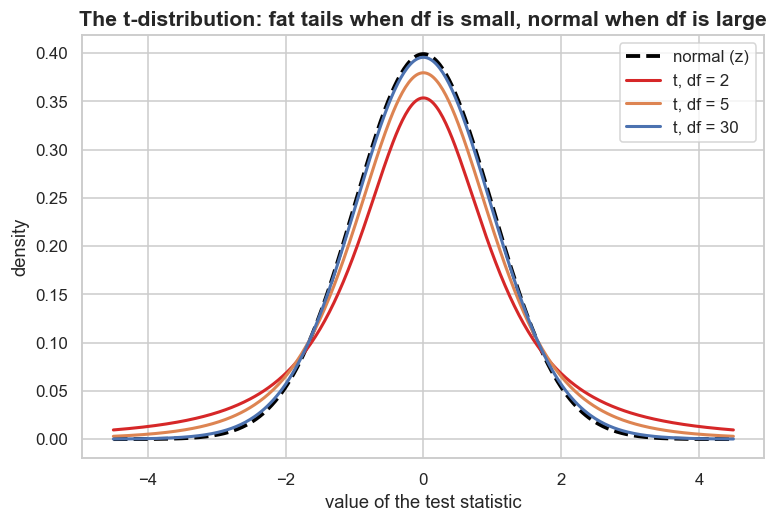

df =    2:  t* (95% two-sided) = 4.303
df =    5:  t* (95% two-sided) = 2.571
df =   30:  t* (95% two-sided) = 2.042
df = 1000:  t* (95% two-sided) = 1.962
normal z* (95% two-sided)        = 1.960   <- the limit t* approaches


In [2]:
xs = np.linspace(-4.5, 4.5, 400)
fig, ax = plt.subplots()
ax.plot(xs, stats.norm.pdf(xs), color='black', lw=2.5, ls='--', label='normal (z)')
for df, col in [(2, '#d62728'), (5, '#dd8452'), (30, '#4c72b0')]:
    ax.plot(xs, stats.t.pdf(xs, df), color=col, lw=2, label=f't, df = {df}')
ax.set_xlabel('value of the test statistic'); ax.set_ylabel('density')
ax.set_title('The t-distribution: fat tails when df is small, normal when df is large')
ax.legend(); plt.show()

# How much fatter are the tails? The 97.5th percentile (the "~2" multiplier) shrinks toward 1.96.
for df in [2, 5, 30, 1000]:
    print(f'df = {df:>4}:  t* (95% two-sided) = {stats.t.ppf(0.975, df):.3f}')
print(f'normal z* (95% two-sided)        = {stats.norm.ppf(0.975):.3f}   <- the limit t* approaches')

The red `df = 2` curve has noticeably heavier tails: with only a couple of data points' worth of
information, extreme t-values are much more likely, so the cutoff for "surprising" is pushed out to
$t^{*} = 4.30$ instead of the normal's $1.96$. By `df = 30` the t-curve has all but merged with the
normal. **Takeaway:** the t-distribution is just the normal's more cautious cousin, and the caution
fades as your sample grows.

## 2) One-sample t-test — is a mean different from a target?

**The question.** Guinea pigs given vitamin C as **orange juice (OJ)** grew tooth cells with some mean
length. Suppose a lab's historical benchmark for this measurement is **18 units**. Is the OJ group's
mean *really* different from 18, or could the gap be sampling noise?

We set up two competing claims:

- **Null hypothesis** $H_0$: the true OJ mean equals the benchmark, $\mu = 18$.
- **Alternative** $H_a$: it does not, $\mu \neq 18$ (a two-sided test).

The plan, simulation-first: **pretend the null is true**, generate the world of t-statistics it would
produce, and see how unusual our actual data looks against it.

In [3]:
oj = tooth.loc[tooth['supp'] == 'OJ', 'len'].to_numpy()
mu0 = 18.0
n = len(oj)
xbar, s = oj.mean(), oj.std(ddof=1)
se = s / np.sqrt(n)
t_obs = (xbar - mu0) / se

print(f'OJ group: n = {n}, mean = {xbar:.2f}, s = {s:.2f}')
print(f'standard error  s/sqrt(n) = {se:.3f}')
print(f'observed t = (mean - 18) / SE = {t_obs:.3f}')

OJ group: n = 30, mean = 20.66, s = 6.61
standard error  s/sqrt(n) = 1.206
observed t = (mean - 18) / SE = 2.208


### Build the null distribution by simulation

If $H_0$ is true and the data were roughly normal, then drawing samples of size $n$ from a population
centered at $\mu_0 = 18$ would produce t-statistics scattered around 0. We don't know the true shape,
but a good stand-in is to **recenter our own sample** so its mean is exactly 18 (forcing $H_0$ to
hold), then **bootstrap-resample** it thousands of times and recompute $t$ each time. The pile of
simulated t's *is* the null distribution — no formula required.

simulated two-sided p-value = 0.0398


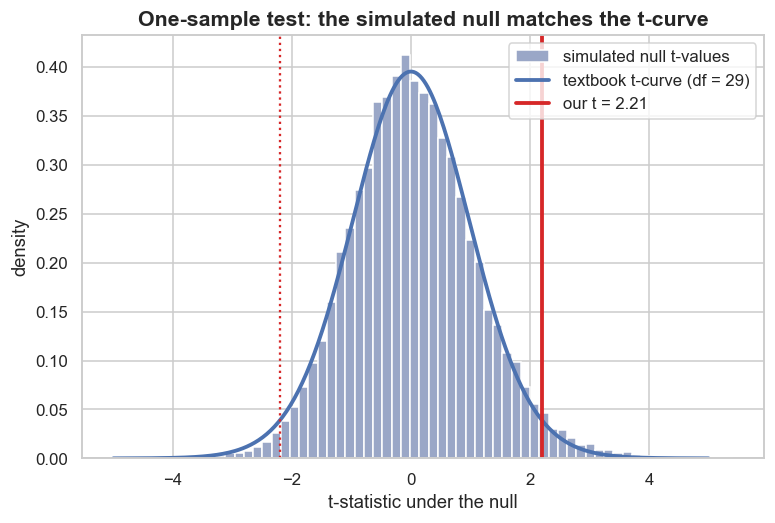

In [4]:
rng = np.random.default_rng(15)        # change this seed to re-roll the simulation
n_sims = 20000

null_centered = oj - xbar + mu0        # shift the sample so its mean is exactly mu0 = 18 (H0 true)
sim_t = np.empty(n_sims)
for i in range(n_sims):
    resample = rng.choice(null_centered, size=n, replace=True)
    sim_t[i] = (resample.mean() - mu0) / (resample.std(ddof=1) / np.sqrt(n))

# Two-sided p-value: how often is a simulated |t| at least as extreme as ours?
p_sim = np.mean(np.abs(sim_t) >= abs(t_obs))
print(f'simulated two-sided p-value = {p_sim:.4f}')

fig, ax = plt.subplots()
ax.hist(sim_t, bins=60, density=True, color='#9aa7c7', edgecolor='white',
        label='simulated null t-values')
grid = np.linspace(-5, 5, 300)
ax.plot(grid, stats.t.pdf(grid, df=n - 1), color='#4c72b0', lw=2.5,
        label=f'textbook t-curve (df = {n-1})')
ax.axvline(t_obs, color='#d62728', lw=2.5, label=f'our t = {t_obs:.2f}')
ax.axvline(-t_obs, color='#d62728', lw=1.5, ls=':')
ax.set_xlabel('t-statistic under the null'); ax.set_ylabel('density')
ax.set_title('One-sample test: the simulated null matches the t-curve')
ax.legend(); plt.show()

Two things to notice. First, the grey histogram of *simulated* null t-values lands right on top of the
blue **textbook t-curve** — that curve is not magic, it is the shape this simulation produces. Second,
our red line at $t = 2.21$ sits out in the thinner part of the curve: only about 3.5% of the null world
is that extreme or worse. Now confirm with the one-line library call.

In [5]:
res = stats.ttest_1samp(oj, popmean=mu0)
print(f'scipy ttest_1samp:  t = {res.statistic:.3f},  p = {res.pvalue:.4f},  df = {res.df}')
print(f'our simulation:     t = {t_obs:.3f},  p = {p_sim:.4f}   (they agree)')

# The confidence interval for the OJ mean is the same machinery, read the other way.
ci = res.confidence_interval(confidence_level=0.95)
print(f'\n95% CI for the true OJ mean: ({ci.low:.2f}, {ci.high:.2f})')
print(f'The target 18 is {"INSIDE" if ci.low <= mu0 <= ci.high else "OUTSIDE"} the interval '
      f'-> consistent with the p-value being {"above" if not (ci.low <= mu0 <= ci.high) else "below"} 0.05? '
      f'(p = {res.pvalue:.3f})')

scipy ttest_1samp:  t = 2.208,  p = 0.0353,  df = 29
our simulation:     t = 2.208,  p = 0.0398   (they agree)

95% CI for the true OJ mean: (18.20, 23.13)
The target 18 is OUTSIDE the interval -> consistent with the p-value being above 0.05? (p = 0.035)


**Reading it three ways:**

- **The math:** $t = (\bar{x}-\mu_0)/(s/\sqrt{n}) = 2.21$ on $df = 29$, giving $p = 0.035$.
- **The meaning:** if the true mean really were 18, we'd see a sample this far from 18 only about 3.5%
  of the time. That's below the usual 5% threshold, so we **reject $H_0$**.
- **The real world:** the OJ group's tooth-cell growth is *statistically* above the benchmark of 18,
  with a 95% CI of roughly $(18.2,\ 23.1)$. Note the CI **just barely excludes** 18 — this is a modest,
  not dramatic, effect. A p-value tells you *whether*; the CI tells you *how much*, and you should
  always report the CI.

> **The CI and the test are the same coin.** A two-sided test rejects $H_0\!: \mu=\mu_0$ at the 5%
> level **exactly when** the 95% CI excludes $\mu_0$. They never disagree.

## 3) Two-sample t-test — comparing two independent groups

Now a different question: forget the benchmark — does the **delivery method** matter? Compare the
**OJ** group against the **VC** (ascorbic-acid) group. These are *different* guinea pigs, so the two
groups are **independent**.

- $H_0$: the two methods have the same true mean ($\mu_{OJ} = \mu_{VC}$), i.e. the difference is 0.
- $H_a$: the means differ ($\mu_{OJ} \neq \mu_{VC}$).

We'll use **Welch's** t-test (`equal_var=False`), the safe default that does **not** assume the two
groups share the same variance. Again, build the null first — this time by **shuffling labels**.

In [6]:
vc = tooth.loc[tooth['supp'] == 'VC', 'len'].to_numpy()
obs_diff = oj.mean() - vc.mean()
print(f'OJ: n = {len(oj)}, mean = {oj.mean():.2f}, s = {oj.std(ddof=1):.2f}')
print(f'VC: n = {len(vc)}, mean = {vc.mean():.2f}, s = {vc.std(ddof=1):.2f}')
print(f'observed difference in means (OJ - VC) = {obs_diff:.2f} units')

OJ: n = 30, mean = 20.66, s = 6.61
VC: n = 30, mean = 16.96, s = 8.27
observed difference in means (OJ - VC) = 3.70 units


### The permutation idea — what if the labels meant nothing?

Here's the cleanest way to picture the null "the method doesn't matter." If the OJ/VC label truly had
no effect, then it's just a *sticker* we slapped on each guinea pig — we could **shuffle the 60 labels
at random** and the gap between the two groups should be no bigger than what we see. So: pool all 60
lengths, repeatedly deal them back into a fake "OJ" pile and "VC" pile, and record the difference in
means each time. That pile of shuffled differences is the null distribution.

> **A fine point.** Label-permutation is technically the exact-test analog of the **pooled**
> (equal-variance) two-sample t-test, not Welch's. It agrees closely with Welch here because the two
> groups are **balanced** ($n = 30$ each), where the pooled and Welch tests nearly coincide.

permutation two-sided p-value = 0.0630


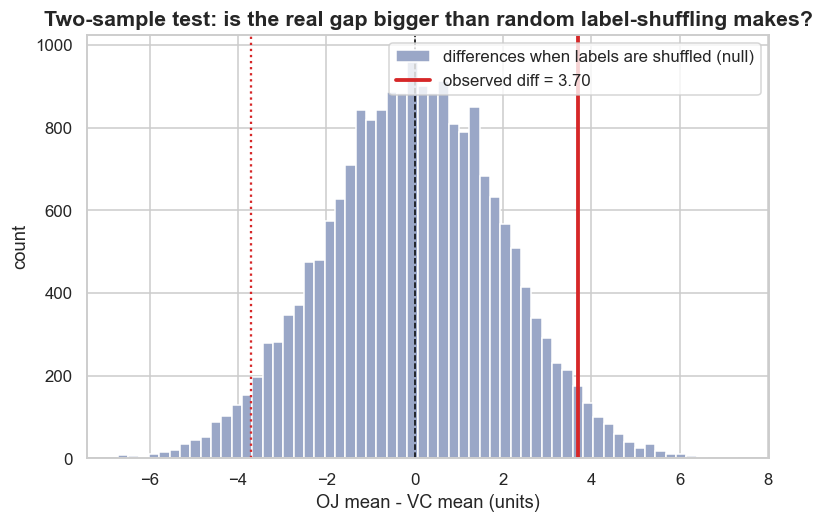

In [7]:
pooled = np.concatenate([oj, vc])
n_oj = len(oj)
perm_diffs = np.empty(n_sims)
for i in range(n_sims):
    rng.shuffle(pooled)
    perm_diffs[i] = pooled[:n_oj].mean() - pooled[n_oj:].mean()

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f'permutation two-sided p-value = {p_perm:.4f}')

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=60, color='#9aa7c7', edgecolor='white',
        label='differences when labels are shuffled (null)')
ax.axvline(obs_diff, color='#d62728', lw=2.5, label=f'observed diff = {obs_diff:.2f}')
ax.axvline(-obs_diff, color='#d62728', lw=1.5, ls=':')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('OJ mean - VC mean (units)'); ax.set_ylabel('count')
ax.set_title('Two-sample test: is the real gap bigger than random label-shuffling makes?')
ax.legend(); plt.show()

In [8]:
welch = stats.ttest_ind(oj, vc, equal_var=False)   # Welch's t-test (unequal variances)
ci = welch.confidence_interval(confidence_level=0.95)
print(f'Welch two-sample t-test:  t = {welch.statistic:.3f},  p = {welch.pvalue:.4f},  df = {welch.df:.1f}')
print(f'permutation test:                       p = {p_perm:.4f}   (close agreement)')
print(f'\n95% CI for the difference (OJ - VC): ({ci.low:.2f}, {ci.high:.2f}) units')
print(f'Zero is {"INSIDE" if ci.low <= 0 <= ci.high else "OUTSIDE"} this interval.')

Welch two-sample t-test:  t = 1.915,  p = 0.0606,  df = 55.3
permutation test:                       p = 0.0630   (close agreement)

95% CI for the difference (OJ - VC): (-0.17, 7.57) units
Zero is INSIDE this interval.


**Reading it:** OJ averaged about 3.7 units higher than VC, but the test gives $p \approx 0.06$ and a
95% CI of roughly $(-0.2,\ 7.6)$ that **straddles zero**. So at the conventional 5% line we **fail to
reject** $H_0$ — the data are *consistent with no real difference*, even though the sample gap looks
sizable.

This is the most important habit in all of inference:

> **"Not significant" does not mean "no effect."** It means *we don't have enough evidence to rule out
> zero.* The CI here runs from a slight OJ disadvantage to a large OJ advantage — we simply can't tell
> yet with only 30 pigs per group. Don't say "OJ and VC are the same"; say "we couldn't detect a
> difference."

## 4) Paired t-test — when the same subjects are measured twice

The two-sample test treats the groups as unrelated. But sometimes each subject gives you **both**
numbers — a before/after, a left/right, a this-suit/that-suit. That's a **paired** design, and ignoring
the pairing throws away its biggest advantage.

The **swim** data is the textbook case: **12 swimmers**, each timed once in a **wetsuit** and once in
a **swimsuit**. The numbers are velocities (metres/second). Because it's the *same swimmer* in both,
the right move is to collapse each pair to its **difference** and ask whether the *mean difference* is
zero.

- $H_0$: the mean within-swimmer difference is 0 (the suit makes no difference).
- $H_a$: the mean difference is not 0.

In [9]:
wet = swim['wet.suit.velocity'].to_numpy()
suit = swim['swim.suit.velocity'].to_numpy()
diff = wet - suit                      # one number per swimmer

print('swimmer  wetsuit  swimsuit  difference')
for i in range(len(diff)):
    print(f'   {i+1:>2}      {wet[i]:.2f}     {suit[i]:.2f}      {diff[i]:+.3f}')
print(f'\nmean difference = {diff.mean():+.4f} m/s   (s = {diff.std(ddof=1):.4f}, n = {len(diff)})')

swimmer  wetsuit  swimsuit  difference
    1      1.57     1.49      +0.080
    2      1.47     1.37      +0.100
    3      1.42     1.35      +0.070
    4      1.35     1.27      +0.080
    5      1.22     1.12      +0.100
    6      1.75     1.64      +0.110
    7      1.64     1.59      +0.050
    8      1.57     1.52      +0.050
    9      1.56     1.50      +0.060
   10      1.53     1.45      +0.080
   11      1.49     1.44      +0.050
   12      1.51     1.41      +0.100

mean difference = +0.0775 m/s   (s = 0.0218, n = 12)


Every single swimmer is faster in the wetsuit (all 12 differences are positive). A paired t-test is
nothing more than a **one-sample t-test on the differences**, testing them against 0. Let's reuse the
exact recipe from Section 2: recenter the differences to have mean 0 (forcing $H_0$), bootstrap, and
read off the p-value.

In [10]:
n_d = len(diff)
t_paired_obs = diff.mean() / (diff.std(ddof=1) / np.sqrt(n_d))

null_d = diff - diff.mean()            # force the mean difference to 0 (H0 true)
sim_td = np.empty(n_sims)
for i in range(n_sims):
    rs = rng.choice(null_d, size=n_d, replace=True)
    sd = rs.std(ddof=1)
    sim_td[i] = rs.mean() / (sd / np.sqrt(n_d)) if sd > 0 else 0.0

p_paired_sim = np.mean(np.abs(sim_td) >= abs(t_paired_obs))
print(f'observed paired t = {t_paired_obs:.2f}')
print(f'simulated null p-value = {p_paired_sim:.6f}   (0 means: never saw anything so extreme)')

# Confirm with scipy two ways: ttest_rel on the pairs == ttest_1samp on the differences.
rel = stats.ttest_rel(wet, suit)
one = stats.ttest_1samp(diff, 0.0)
print(f'\nscipy ttest_rel(wet, suit):   t = {rel.statistic:.2f},  p = {rel.pvalue:.2e}')
print(f'scipy ttest_1samp(diff, 0):   t = {one.statistic:.2f},  p = {one.pvalue:.2e}   (identical)')

ci = one.confidence_interval(confidence_level=0.95)
print(f'\n95% CI for the mean speed gain: ({ci.low:.4f}, {ci.high:.4f}) m/s')

observed paired t = 12.32
simulated null p-value = 0.000000   (0 means: never saw anything so extreme)

scipy ttest_rel(wet, suit):   t = 12.32,  p = 8.89e-08
scipy ttest_1samp(diff, 0):   t = 12.32,  p = 8.89e-08   (identical)

95% CI for the mean speed gain: (0.0637, 0.0913) m/s


The wetsuit advantage is overwhelming: $t \approx 12.3$, $p \approx 9 \times 10^{-8}$, and a 95% CI of
about $(0.064,\ 0.091)$ m/s that sits comfortably above zero. In 20,000 simulated null worlds we
essentially never saw a gap this big by chance.

## 5) Why pairing matters — the headline demonstration

Here's the punchline of the whole lesson. **Watch what happens if we *ignore* the pairing** and (wrongly)
run a two-sample test, treating the 12 wetsuit times and 12 swimsuit times as two unrelated groups.

In [11]:
paired_test = stats.ttest_rel(wet, suit)                       # CORRECT: respects the pairing
unpaired_test = stats.ttest_ind(wet, suit, equal_var=False)    # WRONG here: pretends groups are unrelated

print('SAME 24 numbers, two analyses:')
print(f'  PAIRED   (correct):  t = {paired_test.statistic:6.2f},  p = {paired_test.pvalue:.2e}   -> clearly significant')
print(f'  UNPAIRED (wrong):    t = {unpaired_test.statistic:6.2f},  p = {unpaired_test.pvalue:.3f}   -> NOT significant')

SAME 24 numbers, two analyses:
  PAIRED   (correct):  t =  12.32,  p = 8.89e-08   -> clearly significant
  UNPAIRED (wrong):    t =   1.37,  p = 0.185   -> NOT significant


Same data, opposite verdict. The correct **paired** test screams "the wetsuit is faster"
($p \approx 9\times10^{-8}$); the **unpaired** test shrugs ($p \approx 0.18$). How can ignoring the
pairing flip a slam-dunk result into a null one? The answer is **between-swimmer variation**.

In [12]:
# The standard error is what differs. Compare the two SEs directly.
se_paired = diff.std(ddof=1) / np.sqrt(n_d)
sp = np.sqrt(((len(wet)-1)*wet.var(ddof=1) + (len(suit)-1)*suit.var(ddof=1)) / (len(wet)+len(suit)-2))
se_unpaired = sp * np.sqrt(1/len(wet) + 1/len(suit))

print(f'SE of the difference, PAIRED   = {se_paired:.4f} m/s')
print(f'SE of the difference, UNPAIRED = {se_unpaired:.4f} m/s')
print(f'-> the paired SE is about {se_unpaired/se_paired:.0f}x smaller, so the same gap looks far more decisive.')
print(f'\nWhy? wetsuit & swimsuit speeds are correlated r = {np.corrcoef(wet, suit)[0,1]:.3f}:')
print('a fast swimmer is fast in BOTH suits. Pairing subtracts away that swimmer-to-swimmer spread.')

SE of the difference, PAIRED   = 0.0063 m/s
SE of the difference, UNPAIRED = 0.0566 m/s
-> the paired SE is about 9x smaller, so the same gap looks far more decisive.

Why? wetsuit & swimsuit speeds are correlated r = 0.988:
a fast swimmer is fast in BOTH suits. Pairing subtracts away that swimmer-to-swimmer spread.


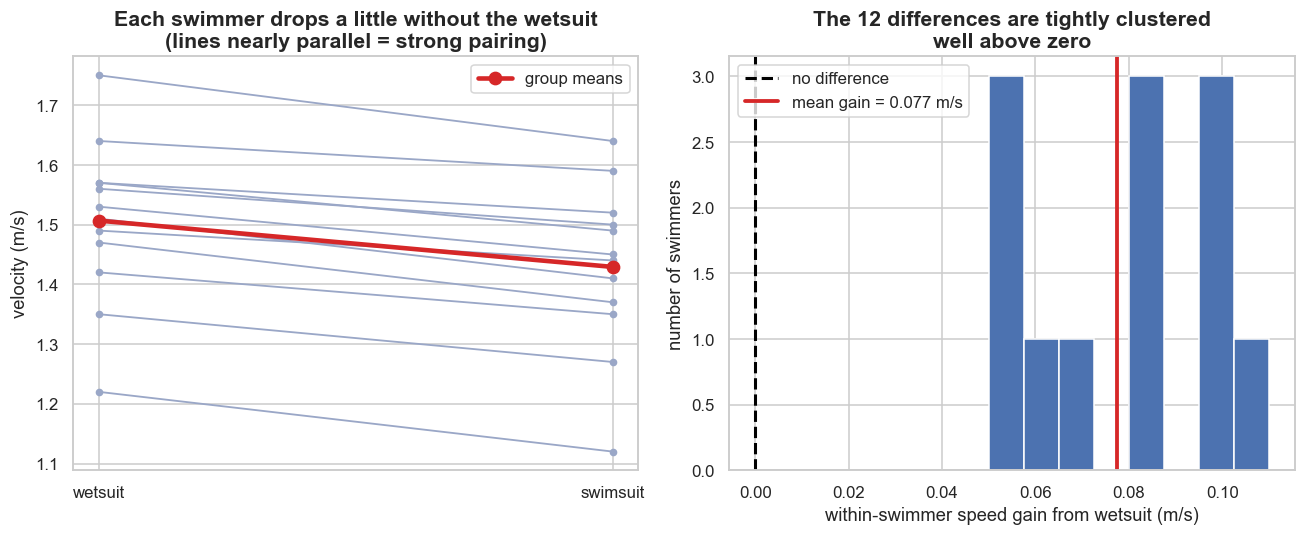

In [13]:
# A picture: connect each swimmer's two times. The lines are nearly parallel and all tilt the same way
# -- THAT consistency is the signal the unpaired test throws away.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(n_d):
    axL.plot([0, 1], [wet[i], suit[i]], color='#9aa7c7', lw=1.2, marker='o', ms=4)
axL.plot([0, 1], [wet.mean(), suit.mean()], color='#d62728', lw=3, marker='o',
         ms=8, label='group means')
axL.set_xticks([0, 1]); axL.set_xticklabels(['wetsuit', 'swimsuit'])
axL.set_ylabel('velocity (m/s)')
axL.set_title('Each swimmer drops a little without the wetsuit\n(lines nearly parallel = strong pairing)')
axL.legend()

axR.hist(diff, bins=8, color='#4c72b0', edgecolor='white')
axR.axvline(0, color='black', lw=2, ls='--', label='no difference')
axR.axvline(diff.mean(), color='#d62728', lw=2.5, label=f'mean gain = {diff.mean():.3f} m/s')
axR.set_xlabel('within-swimmer speed gain from wetsuit (m/s)'); axR.set_ylabel('number of swimmers')
axR.set_title('The 12 differences are tightly clustered\nwell above zero')
axR.legend()
plt.tight_layout(); plt.show()

On the **left**, the 12 connecting lines are nearly parallel — every swimmer loses a similar sliver of
speed without the wetsuit. The *raw* velocities range widely (slow swimmers near 1.2, fast ones near
1.75), and the unpaired test sees that big spread and concludes the two clouds overlap too much to call.
But the **right** panel shows the trick: once you look at each swimmer's *own* change, the 12
differences huddle tightly just above zero. **Pairing cancels the between-swimmer noise**, leaving only
the clean wetsuit effect — which is why the paired SE was ~9x smaller.

**The real-world lesson:** if your data are naturally matched (before/after, twins, left/right,
same-subject), *use the pairing.* It is often the difference between detecting an effect and missing it.

## 6) Assumptions & robustness — when can you trust a t-test?

The t-test isn't unconditional. Its key assumptions:

1. **Independent observations** (within each group). The whole *point* of the paired test is to handle
   the one dependence we expect — the link between a subject's two measurements — by reducing to one
   number per subject.
2. **Roughly normal** data — specifically, the **sampling distribution of the mean** should be near
   normal. For the *paired* test this means the **differences** should be roughly normal, not the raw
   values.
3. For the **two-sample** test, equal variances are *not* required if you use **Welch's** version (the
   default we used).

The good news is **robustness**: thanks to the Central Limit Theorem (the engine from the sampling-
distributions lesson), the t-test holds up well even for non-normal data once $n$ is moderately large,
because the *mean* becomes normal regardless. It's most fragile with **small samples of skewed data
with outliers**. Let's check our swim differences with a quick normal-quantile (Q-Q) plot — if the
points hug the line, normality is a fair assumption.

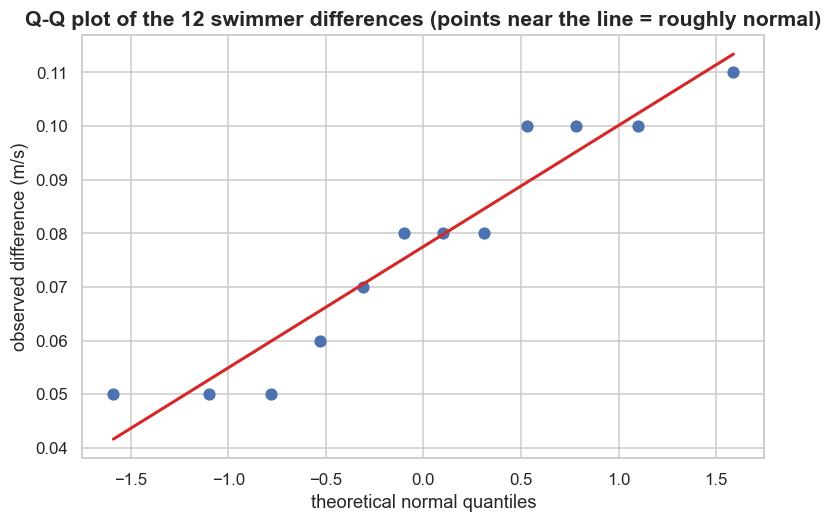

Shapiro-Wilk normality test on the differences: W = 0.898, p = 0.147
p > 0.05 -> no evidence against normality, so the paired t-test is on safe ground.


In [14]:
fig, ax = plt.subplots()
stats.probplot(diff, dist='norm', plot=ax)
ax.get_lines()[0].set_color('#4c72b0'); ax.get_lines()[0].set_markersize(7)
ax.get_lines()[1].set_color('#d62728'); ax.get_lines()[1].set_linewidth(2)
ax.set_title('Q-Q plot of the 12 swimmer differences (points near the line = roughly normal)')
ax.set_xlabel('theoretical normal quantiles'); ax.set_ylabel('observed difference (m/s)')
plt.show()

# A formal sanity check (with only 12 points, treat this gently).
w_stat, w_p = stats.shapiro(diff)
print(f'Shapiro-Wilk normality test on the differences: W = {w_stat:.3f}, p = {w_p:.3f}')
print('p > 0.05 -> no evidence against normality, so the paired t-test is on safe ground.')

## Now you try

Predict the result first, then change a number and re-run:

1. **A different one-sample target.** In Section 2 the benchmark is `mu0 = 18.0`. Change it to `21.0`
   and re-run that cell and the scipy cell. Does the OJ mean now look different from the target, or
   consistent with it? Watch the p-value and whether the 95% CI contains your new target.

2. **A clearly-significant two-sample gap.** Section 3 compared *all* OJ vs *all* VC (a borderline
   $p\approx0.06$). The effect is much stronger at the highest dose. In a new cell, run

       oj2 = tooth[(tooth['supp']=='OJ') & (tooth['dose']==2.0)]['len']
       vc2 = tooth[(tooth['supp']=='VC') & (tooth['dose']==2.0)]['len']
       stats.ttest_ind(oj2, vc2, equal_var=False)

   Is the difference still hard to call, or does it sharpen up? (Note: at dose 2.0 the two methods are
   famously almost identical — predict before you run.)

3. **Break the pairing on purpose.** In Section 5, the magic came from the swimmer-to-swimmer
   correlation (`r = 0.99`). Add a cell that *scrambles* the swimsuit times before pairing:
   `stats.ttest_rel(wet, rng.permutation(suit))`. With the pairing destroyed, does the paired t-test's
   advantage survive?

4. **Re-roll the simulations.** Change `np.random.default_rng(15)` to any other number and re-run the
   simulated null distributions in Sections 2–4. The simulated p-values should shift only in the third
   decimal — confirming the result isn't an artifact of one lucky seed.

## What you learned

- **Why t, not z:** when the population spread $\sigma$ is unknown we estimate it with $s$, adding
  uncertainty; the **t-distribution** absorbs that with heavier tails governed by $df = n-1$, and it
  melts into the normal as $n$ grows.
- A **one-sample t-test** compares one group's mean to a target value, $t = (\bar{x}-\mu_0)/(s/\sqrt{n})$;
  the matching **95% CI** rejects the target exactly when it excludes it.
- A **two-sample (Welch) t-test** compares two *independent* groups' means and hands back a CI for their
  **difference**; a difference that looks big can still be **non-significant**, and "not significant"
  means "couldn't rule out zero," not "no effect."
- A **paired t-test** is just a one-sample t-test on the **within-subject differences** — use it
  whenever the same subjects are measured twice.
- **Pairing matters:** on the swim data the correct paired test ($p\approx10^{-7}$) detected an effect
  the wrong unpaired test missed ($p\approx0.18$), because pairing subtracts away large
  between-subject variation and shrinks the standard error.
- Every test here was first **built by simulation** (bootstrapping a recentered sample, or shuffling
  group labels) and the textbook formula merely *agreed* — the t-curve is the shape the simulation
  produces.
- **Assumptions:** independent observations and roughly-normal *means* (or *differences*); the t-test is
  robust for moderate $n$ thanks to the CLT, and shakiest for small, skewed, outlier-ridden samples —
  check with a Q-Q plot.

---

**← Previous:** [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb)

**Same idea, another way:**  [Another dataset →](15-t-tests~another-dataset.ipynb)  ·  [The code behind it →](15-t-tests~the-code.ipynb)